In [14]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [1]:
import pandas as pd 

sanpham = pd.read_csv("../data/clean/dm_san_pham_clean.csv")
vitri = pd.read_csv("../data/clean/dm_vi_tri_clean.csv")
tonkho = pd.read_csv("../data/clean/xnk_ton_kho_clean.csv")
cham = pd.read_csv("../data/clean/log_cham_hang.csv")
xuatkho = pd.read_csv("../data/clean/xnk_xuat_kho_clean.csv")
nhapkho = pd.read_csv("../data/clean/xnk_nhap_kho_clean.csv")
nhapkhopicklist = pd.read_csv("../data/clean/xnk_nhap_kho_picklist_clean.csv")

C:\Users\anhkh\AppData\Local\Temp\ipykernel_18564\118592328.py:3: DtypeWarning: Columns (6,39,40) have mixed types. Specify dtype option on import or set low_memory=False.
  sanpham = pd.read_csv("../data/clean/dm_san_pham_clean.csv")
C:\Users\anhkh\AppData\Local\Temp\ipykernel_18564\118592328.py:7: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  xuatkho = pd.read_csv("../data/clean/xnk_xuat_kho_clean.csv")
C:\Users\anhkh\AppData\Local\Temp\ipykernel_18564\118592328.py:8: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  nhapkho = pd.read_csv("../data/clean/xnk_nhap_kho_clean.csv")
C:\Users\anhkh\AppData\Local\Temp\ipykernel_18564\118592328.py:9: DtypeWarning: Columns (7,8,9,12,25,26) have mixed types. Specify dtype option on import or set low_memory=False.
  nhapkhopicklist = pd.read_csv("../data/clean/xnk_nhap_kho_picklist_clean.csv")


In [9]:
print(xuatkho.columns.tolist())
print(cham.columns.tolist())
print(tonkho.columns.tolist())

['auto_id', 'chu_hang_id', 'kho_id', 'xuat_kho_id', 'xuat_kho_raw_data_id', 'vi_tri_id', 'ton_kho_id', 'nhap_kho_id', 'san_pham_id', 'so_po', 'ngay_san_xuat', 'ngay_het_han', 'line_item', 'ngay_nhap_kho_root', 'so_lpn', 'so_kien_allocated', 'sl_allocated_chan', 'sl_allocated_le', 'sl_allocated_all_special', 'so_kien_ton_on_allocated', 'sl_ton_chan_on_allocated', 'sl_ton_le_on_allocated', 'sl_ton_all_special_on_allocated', 'don_gia_nhap', 'don_gia_xuat', 'gw', 'nw', 'cbm', 'deleted']
['auto_id', 'chu_hang_id', 'kho_id', 'san_pham_id', 'xuat_kho_id', 'ton_kho_id', 'so_lpn', 'ma_so_vi_tri_cu', 'ma_so_vi_tri_moi', 'so_kien_repleshniment', 'sl_repleshniment_chan', 'sl_repleshniment_le', 'sl_repleshniment_all_special', 'trang_thai_id', 'is_repleshniment_sau', 'deleted', 'created', 'created_by', 'created_by_function', 'last_updated', 'last_updated_by', 'last_updated_by_function', 'nv_cham_hang', 'ngay_gio_bd_cham', 'ngay_gio_kt_cham', 'ma_so_vi_tri_actual']
['auto_id', 'chu_hang_id', 'kho_id'

In [36]:
import importlib
import src.feature.basic
import src.feature.merge

importlib.reload(src.feature.basic)
importlib.reload(src.feature.merge)

<module 'src.feature.merge' from 'e:\\TKsolution\\warehouse AI\\src\\feature\\merge.py'>

In [44]:
from src.feature.merge import build_feature_table

feature_table, location_feature = build_feature_table(
    sanpham,
    tonkho,
    xuatkho,
    cham,
    vitri
)

display(feature_table.head())
display(location_feature.head())

,san_pham_id,chu_hang_id,nhom_nganh_hang_id,nganh_hang_id,loai_san_pham_id,don_vi_tinh_id,don_vi_tinh_thung_id,ma_san_pham,ten_san_pham,sl_cai_1_thung,...,tong_xuat,so_lan_xuat,so_don_xuat,so_lpn_da_xuat,tong_cham,so_lan_cham,so_lpn_cham,inventory_turnover,replenishment_ratio,pick_density
0,12504073.0,12473661.0,0.0,12501018.0,12500320.0,12499665.0,0,40000001.0,SP0000001,12.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
1,20003159.0,12473661.0,0.0,12501018.0,12500320.0,12499665.0,12499662,40000002.0,SP0000002,8.0,...,56.0,7.0,6.0,1.0,0.0,0.0,0.0,1.400000,0.000000,14.000000
2,12504099.0,12473661.0,0.0,12501018.0,12500320.0,12499665.0,0,40000003.0,SP0000003,8.0,...,256.0,21.0,17.0,3.0,80.0,1.0,1.0,1.280000,0.312500,42.666667
3,12504065.0,12473661.0,0.0,12501018.0,12500320.0,12499665.0,0,40000004.0,SP0000004,12.0,...,1314.0,94.0,67.0,14.0,780.0,6.0,5.0,1.023364,0.593607,82.125000
4,12504075.0,12473661.0,0.0,12501018.0,12500320.0,12499665.0,0,40000005.0,SP0000005,12.0,...,372.0,34.0,33.0,7.0,684.0,7.0,6.0,0.407895,1.838710,21.882353


,vi_tri_id,tong_ton,so_sku,so_lpn,kho_id,day_ke_id,ma_so_vi_tri,tang,dai,rong,cao,vi_tri_type_id,vi_tri_seq_id,tag,sl_pallet,sl_sku,gw_max,cbm_max,trang_thai_id,ghi_chu
0,12473819,812.0,58,110,12473657,12473811,HZ7,1,92.384492,110.856971,115.242266,15,0,NaN,0.0,0.0,0.0,1.405236e+06,1,Hàng đợi NCC xử lý đôi
1,12473823,7488.0,148,188,12473657,12473811,HZ5,1,92.384492,110.856971,115.242266,15,0,NaN,0.0,0.0,0.0,1.405236e+06,1,Hàng vấn đề về date
2,12473825,2418.0,717,967,12473657,12473811,HZ4,1,92.384492,110.856971,115.242266,12,0,NaN,0.0,0.0,0.0,1.405236e+06,1,Hàng xuất trả
3,12473827,8972.0,108,111,12473657,12473811,HZ3,1,92.384492,110.856971,115.242266,15,0,NaN,0.0,0.0,0.0,1.405236e+06,1,Hàng biên bản nhà cung cấp
4,12473829,6008.0,176,145,12473657,12473811,HZ2,1,92.384492,110.856971,115.242266,15,0,NaN,0.0,0.0,0.0,1.405236e+06,1,Hàng thất lạc


In [38]:
feature_table.shape
location_feature.shape

(14436, 20)

In [39]:
feature_table.isna().sum().sort_values(ascending=False)

ghi_chu                   348077
replenishment_ratio       341417
inventory_turnover        340017
pick_density              339977
san_pham_type_id              23
so_lpn                         0
carton_dai                     0
carton_rong                    0
carton_cao                     0
pcs_dai                        0
pcs_rong                       0
pcs_cao                        0
trang_thai_id                  0
tong_ton                       0
tong_xuat_thuc_te              0
tong_so_kien                   0
so_vi_tri                      0
barcode_item_4                 0
tong_gw                        0
tong_nw                        0
tong_cbm                       0
tong_xuat                      0
so_lan_xuat                    0
so_don_xuat                    0
so_lpn_da_xuat                 0
tong_cham                      0
so_lan_cham                    0
so_lpn_cham                    0
barcode_item_5                 0
san_pham_id                    0
chu_hang_i

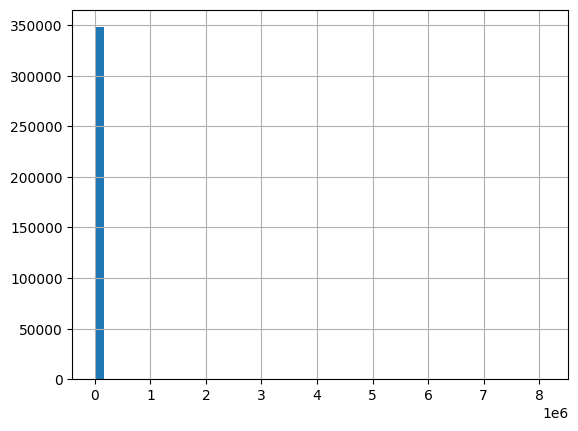

In [42]:
import matplotlib.pyplot as plt

feature_table["tong_ton"].hist(bins=50)
plt.show()

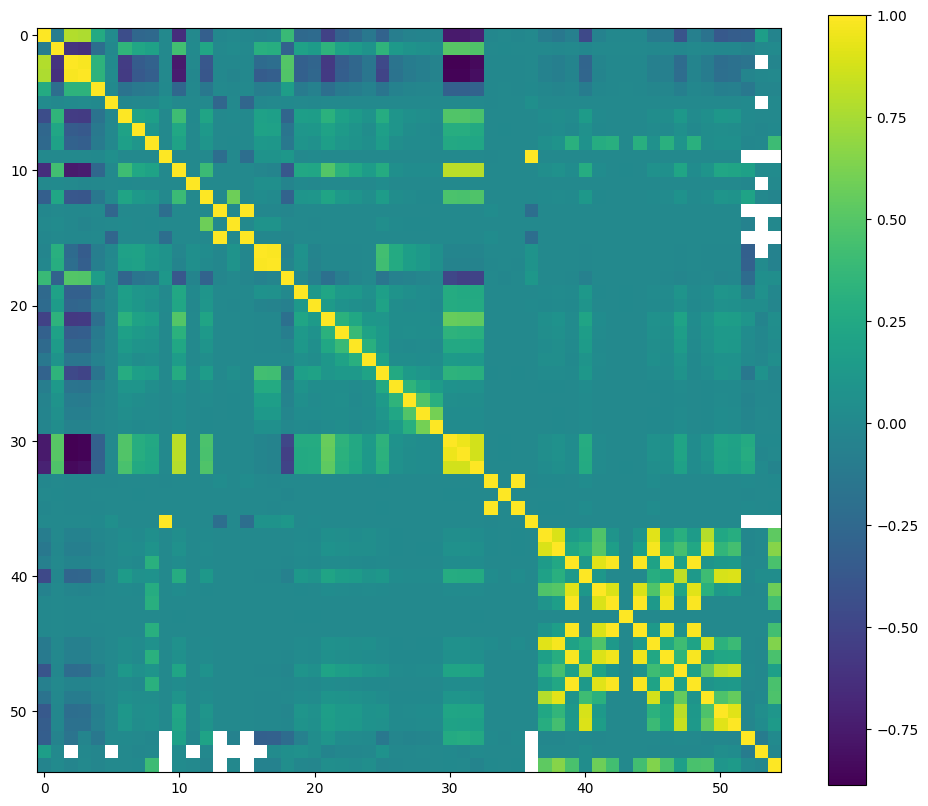

In [43]:
import matplotlib.pyplot as plt

corr = feature_table.select_dtypes("number").corr()

plt.figure(figsize=(12,10))
plt.imshow(corr)
plt.colorbar()
plt.show()

In [45]:
from src.dataset.dataset import build_warehouse_dataset

warehouse_dataset = build_warehouse_dataset(
    feature_table,
    tonkho
)

In [46]:
warehouse_dataset.head()

,san_pham_id,chu_hang_id,nhom_nganh_hang_id,nganh_hang_id,loai_san_pham_id,don_vi_tinh_id,don_vi_tinh_thung_id,ma_san_pham,ten_san_pham,sl_cai_1_thung,...,so_lan_xuat,so_don_xuat,so_lpn_da_xuat,tong_cham,so_lan_cham,so_lpn_cham,inventory_turnover,replenishment_ratio,pick_density,kho_id
0,20003159.0,12473661.0,0.0,12501018.0,12500320.0,12499665.0,12499662,40000002.0,SP0000002,8.0,...,7.0,6.0,1.0,0.0,0.0,0.0,1.400000,0.000000,14.000000,12473657
1,12504099.0,12473661.0,0.0,12501018.0,12500320.0,12499665.0,0,40000003.0,SP0000003,8.0,...,21.0,17.0,3.0,80.0,1.0,1.0,1.280000,0.312500,42.666667,12473657
2,12504065.0,12473661.0,0.0,12501018.0,12500320.0,12499665.0,0,40000004.0,SP0000004,12.0,...,94.0,67.0,14.0,780.0,6.0,5.0,1.023364,0.593607,82.125000,12473657
3,12504075.0,12473661.0,0.0,12501018.0,12500320.0,12499665.0,0,40000005.0,SP0000005,12.0,...,34.0,33.0,7.0,684.0,7.0,6.0,0.407895,1.838710,21.882353,12473657
4,12505475.0,12473661.0,0.0,12501018.0,12500326.0,12499665.0,0,40000006.0,SP0000006,36.0,...,269.0,249.0,21.0,13356.0,40.0,20.0,0.657143,1.240803,239.200000,12473657
